## Intelligent Loan Risk Assessment & Approval Orchestration


In [36]:
!pip install -q langgraph langchain langchain-google-genai

In [37]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
import os, time, re

In [38]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY,
    temperature=0
)

---
## State Definition

In [39]:
class LoanState(TypedDict):

    #Raw Input
    application_text: str
    documents_provided: str

    #Stage 1: Applicant Analysis
    applicant_name: str
    employment_type: str
    monthly_income: float
    loan_amount_requested: float
    loan_tenure_years: int
    existing_debts: float
    credit_score: int
    income_stability: str
    spending_pattern: str
    financial_behavior_score: int
    missing_documents: str

    # Stage 2: Verification Layer
    credit_bureau_status: str
    fraud_score: int
    fraud_flags: str
    kyc_status: str
    employment_verified: bool
    debt_to_income_ratio: float
    overall_risk_level: str

    # Stage 3: Routing & Agent Decision
    route: str
    agent_decision: str
    agent_rationale: str

    # Stage 4: Decision Orchestration
    decision_rationale: str
    risk_summary: str
    recommended_loan_amount: float
    suggested_interest_rate: str
    applicant_notification: str
    final_decision_report: str

### STAGE 1 — Applicant Analysis

In [40]:
#applicant understanding node
def applicant_understanding(state: LoanState):
    """Single LLM call — extracts all structured applicant fields from free-text."""

    prompt = f"""
    You are a loan processing AI at a financial institution.

    Extract structured information from this loan application.

    Application:
    {state['application_text']}

    Documents submitted: {state.get('documents_provided', 'none mentioned')}

    Return ONLY in this exact format (no extra text, no markdown):

    applicant_name: <full name>
    employment_type: <salaried / self_employed / freelance / unemployed>
    monthly_income: <number only, in same currency as application>
    loan_amount_requested: <number only>
    loan_tenure_years: <integer>
    existing_debts: <monthly EMI obligations as number, 0 if none>
    credit_score: <integer 300-900, estimate if not given>
    """

    text = llm.invoke(prompt).content

    result = {}
    for line in text.strip().split("\n"):
        if ":" in line:
            key, value = line.split(":", 1)
            result[key.strip()] = value.strip()

    def safe_float(val, default=0.0):
        try:
            return float(re.sub(r"[^\d.]", "", val))
        except:
            return default

    def safe_int(val, default=0):
        try:
            return int(re.sub(r"[^\d]", "", val))
        except:
            return default

    return {
        "applicant_name":        result.get("applicant_name", "Applicant"),
        "employment_type":       result.get("employment_type", "salaried"),
        "monthly_income":        safe_float(result.get("monthly_income", "0")),
        "loan_amount_requested": safe_float(result.get("loan_amount_requested", "0")),
        "loan_tenure_years":     safe_int(result.get("loan_tenure_years", "5")),
        "existing_debts":        safe_float(result.get("existing_debts", "0")),
        "credit_score":          safe_int(result.get("credit_score", "650")),
        "missing_documents":     ""
    }

In [41]:
#profile extraction node
def profile_extraction(state: LoanState):
    """Rule-based: validates and normalises extracted profile fields."""

    income  = state.get("monthly_income", 0)
    loan    = state.get("loan_amount_requested", 0)
    tenure  = state.get("loan_tenure_years", 5)
    emptype = state.get("employment_type", "salaried").lower()

    # Clamp and clean values
    income  = max(0, income)
    loan    = max(0, loan)
    tenure  = max(1, min(30, tenure))
    emptype = emptype if emptype in ["salaried", "self_employed", "freelance", "unemployed"] else "salaried"

    return {
        "monthly_income":        income,
        "loan_amount_requested": loan,
        "loan_tenure_years":     tenure,
        "employment_type":       emptype
    }

In [42]:
# income stability check node
def income_stability_check(state: LoanState):
    """Rule-based: classifies income stability from employment type + income level."""

    emptype = state.get("employment_type", "salaried").lower()
    income  = state.get("monthly_income", 0)

    if emptype == "unemployed":
        stability = "unstable"
    elif emptype == "freelance":
        stability = "moderate" if income >= 50000 else "unstable"
    elif emptype == "self_employed":
        stability = "stable" if income >= 80000 else "moderate"
    else:  # salaried
        stability = "stable" if income >= 30000 else "moderate"

    return {"income_stability": stability}

In [43]:
#spending pattern analysis node
def spending_pattern_analysis(state: LoanState):
    """Rule-based: infers spending behaviour from existing debts vs income."""

    income = state.get("monthly_income", 1)
    debts  = state.get("existing_debts", 0)

    if income == 0:
        return {"spending_pattern": "aggressive"}

    debt_ratio = debts / income

    if debt_ratio < 0.20:
        pattern = "conservative"
    elif debt_ratio < 0.40:
        pattern = "moderate"
    else:
        pattern = "aggressive"

    return {"spending_pattern": pattern}

In [44]:
#fianncial behaviour score
def financial_behavior_score(state: LoanState):
    """Rule-based: computes 0–100 internal financial behaviour score."""

    score = 50   # baseline

    # Credit score contribution (max +30)
    cs = state.get("credit_score", 650)
    if cs >= 800:   score += 30
    elif cs >= 750: score += 22
    elif cs >= 700: score += 15
    elif cs >= 650: score += 8
    elif cs >= 600: score += 0
    else:           score -= 15

    # Employment type contribution
    emptype = state.get("employment_type", "salaried")
    if emptype == "salaried":      score += 10
    elif emptype == "self_employed": score += 5
    elif emptype == "freelance":   score += 0
    else:                          score -= 20   # unemployed

    # Spending pattern contribution
    pattern = state.get("spending_pattern", "moderate")
    if pattern == "conservative":  score += 10
    elif pattern == "moderate":    score += 5
    else:                          score -= 10

    return {"financial_behavior_score": min(100, max(0, score))}

In [45]:
#Gate Node
def document_completeness_gate(state: LoanState):
    """Fan-in after Stage 1 parallel nodes.
    Checks whether critical documents are missing — if so, flags for early exit.
    No LLM.
    """

    provided = state.get("documents_provided", "").lower()
    missing  = state.get("missing_documents", "")

    # Always require these core documents
    required = ["salary slip", "bank statement", "id proof", "address proof"]
    rule_missing = [doc for doc in required if doc not in provided]

    # Combine LLM-detected + rule-detected missing docs
    if rule_missing:
        combined = missing + ", " + ", ".join(rule_missing) if missing else ", ".join(rule_missing)
        # Deduplicate
        items = list(dict.fromkeys([x.strip() for x in combined.split(",") if x.strip()]))
        combined = ", ".join(items)
    else:
        combined = missing

    return {"missing_documents": combined}


def documents_gate_decision(state: LoanState) -> str:
    """Conditional edge: missing docs → early exit to clarification_agent."""
    if state.get("missing_documents", "").strip():
        return "missing_docs"
    return "proceed_to_verification"

### STAGE 2 — Verification Layer

In [46]:
#Verification Node 1/5
def credit_bureau_validation(state: LoanState):
    """Rule-based credit bureau check based on credit score bands. No LLM."""

    cs = state.get("credit_score", 650)

    if cs >= 750:
        status = "verified"
    elif cs >= 650:
        status = "verified"       # Acceptable range — verified with note
    elif cs >= 580:
        status = "flagged"        # Below acceptable — needs manual review
    else:
        status = "insufficient_history"  # Too low or no credit history

    return {"credit_bureau_status": status}

In [47]:
#Verification Node 2/5
def fraud_detection(state: LoanState):
    """Rule-based fraud signal scoring. No LLM.

    Checks for common fraud indicators:
    - Loan amount >> income (loan-to-income ratio)
    - Unemployed with high loan request
    - Unusually high credit score claim with missing docs
    - Very short tenure for very large loan
    """

    income   = state.get("monthly_income", 1)
    loan     = state.get("loan_amount_requested", 0)
    emptype  = state.get("employment_type", "salaried")
    cs       = state.get("credit_score", 650)
    missing  = state.get("missing_documents", "")
    tenure   = state.get("loan_tenure_years", 5)

    fraud_score = 0
    flags = []

    # Loan-to-annual-income ratio > 10× is suspicious
    annual_income = income * 12
    if annual_income > 0 and loan / annual_income > 10:
        fraud_score += 35
        flags.append(f"Loan ({loan:,.0f}) is >10× annual income ({annual_income:,.0f})")

    # Unemployed + large loan
    if emptype == "unemployed" and loan > 100000:
        fraud_score += 30
        flags.append("Unemployed applicant requesting large loan")

    # High credit score claim but missing documents
    if cs > 800 and missing:
        fraud_score += 20
        flags.append("High credit score claimed but documents missing")

    # Very short tenure for very large amount (predatory intent signal)
    if tenure <= 1 and loan > 500000:
        fraud_score += 15
        flags.append("Very short repayment tenure for large loan amount")

    fraud_score = min(100, fraud_score)
    flags_str = "; ".join(flags) if flags else "No fraud indicators detected"

    return {
        "fraud_score": fraud_score,
        "fraud_flags": flags_str
    }

In [48]:
#Verification Node 3/5
def kyc_verification(state: LoanState):
    """Rule-based KYC check based on submitted documents. No LLM."""

    provided = state.get("documents_provided", "").lower()
    missing  = state.get("missing_documents", "")

    kyc_docs = ["id proof", "address proof", "pan card", "aadhaar", "passport"]
    kyc_found = any(doc in provided for doc in kyc_docs)

    if missing and any(doc in missing.lower() for doc in ["id", "address", "kyc"]):
        status = "failed"
    elif kyc_found:
        status = "verified"
    else:
        status = "pending"

    return {"kyc_status": status}

In [49]:
#Verification Node 4/5
def employment_verification(state: LoanState):
    """Rule-based employment check. No LLM."""

    provided = state.get("documents_provided", "").lower()
    emptype  = state.get("employment_type", "salaried").lower()

    salaried_docs = ["salary slip", "offer letter", "employment letter", "form 16"]
    selfempl_docs = ["itr", "gst", "business registration", "ca certificate"]

    if emptype == "unemployed":
        verified = False
    elif emptype == "salaried":
        verified = any(doc in provided for doc in salaried_docs)
    else:  # self_employed / freelance
        verified = any(doc in provided for doc in selfempl_docs)

    return {"employment_verified": verified}

In [50]:
#Verification Node 5/5
def debt_to_income_calculation(state: LoanState):
    """Rule-based DTI calculation.

    DTI = (existing_debts + proposed_EMI) / monthly_income
    Proposed EMI estimated using flat rate approximation.
    No LLM.
    """

    income  = state.get("monthly_income", 1)
    debts   = state.get("existing_debts", 0)
    loan    = state.get("loan_amount_requested", 0)
    tenure  = state.get("loan_tenure_years", 5)
    cs      = state.get("credit_score", 650)

    # Estimate interest rate from credit score
    if cs >= 780:  annual_rate = 0.085
    elif cs >= 720: annual_rate = 0.105
    elif cs >= 660: annual_rate = 0.125
    else:           annual_rate = 0.155

    # EMI = P * r * (1+r)^n / ((1+r)^n - 1)
    r = annual_rate / 12
    n = tenure * 12
    if r > 0 and n > 0:
        proposed_emi = loan * r * (1 + r)**n / ((1 + r)**n - 1)
    else:
        proposed_emi = loan / max(n, 1)

    total_obligations = debts + proposed_emi
    dti = round(total_obligations / max(income, 1), 4)

    return {"debt_to_income_ratio": dti}

In [51]:
#Risk Aggregator
def risk_aggregator(state: LoanState):
    """Fan-in node — aggregates all 5 verification outputs into overall_risk_level.
    """

    fraud       = state.get("fraud_score", 0)
    dti         = state.get("debt_to_income_ratio", 0)
    cs          = state.get("credit_score", 650)
    kyc         = state.get("kyc_status", "verified")
    emp_verified= state.get("employment_verified", False)
    bureau      = state.get("credit_bureau_status", "verified")
    behav       = state.get("financial_behavior_score", 50)

    risk_points = 0

    # Fraud score
    if fraud >= 60:    risk_points += 4
    elif fraud >= 30:  risk_points += 2

    # DTI
    if dti > 0.60:    risk_points += 4
    elif dti > 0.45:  risk_points += 2
    elif dti > 0.35:  risk_points += 1

    # Credit score
    if cs < 600:      risk_points += 3
    elif cs < 680:    risk_points += 1

    # KYC
    if kyc == "failed":   risk_points += 3
    elif kyc == "pending": risk_points += 1

    # Employment
    if not emp_verified:  risk_points += 2

    # Bureau
    if bureau == "insufficient_history": risk_points += 2
    elif bureau == "flagged":            risk_points += 3

    # Behaviour score
    if behav < 40:    risk_points += 2
    elif behav >= 80: risk_points -= 1

    if risk_points >= 8:    risk = "critical"
    elif risk_points >= 5:  risk = "high"
    elif risk_points >= 2:  risk = "medium"
    else:                   risk = "low"

    return {"overall_risk_level": risk}

### STAGE 3 — Intelligent Routing & Decision Agents

In [52]:
def intelligent_router(state: LoanState):
    """Rule-based loan application router. No LLM."""

    fraud   = state.get("fraud_score", 0)
    cs      = state.get("credit_score", 650)
    risk    = state.get("overall_risk_level", "medium")
    dti     = state.get("debt_to_income_ratio", 0)
    missing = state.get("missing_documents", "")
    behav   = state.get("financial_behavior_score", 50)

    # Priority 1: High fraud risk
    if fraud >= 50:
        route = "fraud_investigation_agent"

    # Priority 2: Excellent profile — fast track
    elif cs >= 750 and risk == "low" and dti < 0.35 and behav >= 70:
        route = "fast_track_approval_agent"

    # Priority 3: Missing documents
    elif missing.strip():
        route = "clarification_agent"

    # Priority 4: Critical risk or extreme DTI — reject
    elif risk == "critical" or dti > 0.65:
        route = "rejection_agent"

    # Priority 5: Medium/high risk — manual review
    elif risk in ["medium", "high"]:
        route = "manual_review_agent"

    # Default: approve
    else:
        route = "fast_track_approval_agent"

    return {"route": route}


def route_decision(state: LoanState) -> str:
    return state["route"]

In [53]:
# Shared Helper
def _call_decision_llm(role: str, decision: str, context: str, state: LoanState) -> str:
    """Shared LLM call for all decision agents.
    Generates personalised, professional rationale for the applicant.
    """

    prompt = f"""
    You are a {role} at a financial institution.

    Write a professional, empathetic loan decision communication for the applicant.

    Applicant: {state.get('applicant_name', 'Applicant')}
    Decision: {decision.upper()}

    Application Details:
    - Loan Requested : {state.get('loan_amount_requested', 0):,.0f}
    - Monthly Income : {state.get('monthly_income', 0):,.0f}
    - Credit Score   : {state.get('credit_score', 0)}
    - Employment     : {state.get('employment_type', 'N/A')}
    - DTI Ratio      : {state.get('debt_to_income_ratio', 0):.1%}
    - Risk Level     : {state.get('overall_risk_level', 'N/A').upper()}
    - Fraud Score    : {state.get('fraud_score', 0)}/100
    - Fraud Flags    : {state.get('fraud_flags', 'None')}
    - KYC Status     : {state.get('kyc_status', 'N/A')}
    - Missing Docs   : {state.get('missing_documents', 'None') or 'None'}

    {context}

    Provide:
    1. Decision rationale (2–3 sentences, professional tone)
    2. Key factors that influenced this decision
    3. Next steps for the applicant (what they should do)

    Keep the tone respectful and constructive.
    """

    return llm.invoke(prompt).content

In [54]:
def fast_track_approval_agent(state: LoanState):
    """Excellent profile, expedited approval path."""

    rationale = _call_decision_llm(
        role="Senior Loan Approval Officer",
        decision="APPROVED — Fast Track",
        context="This applicant has an excellent profile. Congratulate them and outline the fast-track process.",
        state=state
    )
    return {
        "agent_decision": "approved",
        "agent_rationale": rationale
    }


def fraud_investigation_agent(state: LoanState):
    """ High fraud probability detected."""

    rationale = _call_decision_llm(
        role="Fraud Investigation Officer",
        decision="UNDER INVESTIGATION",
        context="Fraud indicators detected. Inform the applicant their application is under investigation without revealing specific detection methods.",
        state=state
    )
    return {
        "agent_decision": "escalated",
        "agent_rationale": rationale
    }


def clarification_agent(state: LoanState):
    """Missing documents, request resubmission."""

    rationale = _call_decision_llm(
        role="Loan Processing Officer",
        decision="PENDING — Documents Required",
        context=f"The following documents are missing: {state.get('missing_documents', 'unspecified')}. Politely request them.",
        state=state
    )
    return {
        "agent_decision": "pending_docs",
        "agent_rationale": rationale
    }


def manual_review_agent(state: LoanState):
    """Medium risk, sent for human review."""

    rationale = _call_decision_llm(
        role="Credit Risk Analyst",
        decision="UNDER REVIEW",
        context="Application requires manual credit risk assessment. Inform the applicant it is being reviewed by a specialist.",
        state=state
    )
    return {
        "agent_decision": "under_review",
        "agent_rationale": rationale
    }


def rejection_agent(state: LoanState):
    """High DTI or critical risk — rejection with constructive guidance."""

    rationale = _call_decision_llm(
        role="Loan Decision Officer",
        decision="DECLINED",
        context="Application does not meet lending criteria. Be respectful and provide actionable improvement tips.",
        state=state
    )
    return {
        "agent_decision": "rejected",
        "agent_rationale": rationale
    }

### STAGE 4 — Decision Orchestration

In [55]:
def generate_rationale(state: LoanState):
    """Structured decision rationale from collected state."""

    decision = state.get("agent_decision", "under_review").upper().replace("_", " ")

    positives, concerns = [], []

    cs = state.get("credit_score", 0)
    if cs >= 750:   positives.append(f"Excellent credit score ({cs})")
    elif cs >= 680: positives.append(f"Good credit score ({cs})")
    else:           concerns.append(f"Below-average credit score ({cs})")

    dti = state.get("debt_to_income_ratio", 0)
    if dti < 0.35:  positives.append(f"Healthy debt-to-income ratio ({dti:.1%})")
    elif dti < 0.50: concerns.append(f"Elevated DTI ratio ({dti:.1%})")
    else:            concerns.append(f"High DTI ratio ({dti:.1%}) — significant debt burden")

    stability = state.get("income_stability", "moderate")
    if stability == "stable":   positives.append("Stable income source")
    elif stability == "unstable": concerns.append("Unstable income pattern")

    if state.get("employment_verified"): positives.append("Employment successfully verified")
    else:                                 concerns.append("Employment could not be verified")

    if state.get("fraud_score", 0) >= 50:
        concerns.append(f"Fraud indicators detected (score: {state['fraud_score']}/100)")

    pos_text = "\n  + ".join(positives) if positives else "None"
    con_text = "\n  - ".join(concerns) if concerns else "None"

    rationale = (
        f"Decision   : {decision}\n"
        f"Positives  :\n  + {pos_text}\n"
        f"Concerns   :\n  - {con_text}"
    )

    return {"decision_rationale": rationale}

In [56]:
def create_risk_summary(state: LoanState):
    """Tabular risk summary from all verification outputs."""

    dti      = state.get("debt_to_income_ratio", 0)
    fraud    = state.get("fraud_score", 0)
    behavior = state.get("financial_behavior_score", 0)

    def risk_tag(val, thresholds, labels):
        for t, l in zip(thresholds, labels):
            if val <= t: return l
        return labels[-1]

    dti_tag   = risk_tag(dti,   [0.35, 0.50, 0.65], ["LOW", "MEDIUM", "HIGH", "CRITICAL"])
    fraud_tag = risk_tag(fraud, [20,   40,   60],    ["LOW", "MEDIUM", "HIGH", "CRITICAL"])
    beh_tag   = risk_tag(100 - behavior, [20, 40, 60], ["LOW", "MEDIUM", "HIGH", "CRITICAL"])

    summary = (
        f"{'Metric':<30} {'Value':<20} {'Risk Tag':<12}\n"
        f"{'─'*62}\n"
        f"{'Credit Score':<30} {state.get('credit_score', 0):<20} {state.get('credit_bureau_status', 'N/A').upper():<12}\n"
        f"{'Debt-to-Income Ratio':<30} {dti:<20.1%} {dti_tag:<12}\n"
        f"{'Fraud Score':<30} {fraud:<20} {fraud_tag:<12}\n"
        f"{'Financial Behaviour Score':<30} {behavior:<20} {beh_tag:<12}\n"
        f"{'KYC Status':<30} {state.get('kyc_status', 'N/A').upper():<20} {'─':<12}\n"
        f"{'Employment Verified':<30} {'YES' if state.get('employment_verified') else 'NO':<20} {'─':<12}\n"
        f"{'─'*62}\n"
        f"{'OVERALL RISK':<30} {state.get('overall_risk_level', 'N/A').upper():<20}\n"
    )

    return {"risk_summary": summary}

In [57]:
def recommend_loan_amount(state: LoanState):
    """Rule-based: recommends an appropriate loan amount based on risk + income."""

    income    = state.get("monthly_income", 0)
    requested = state.get("loan_amount_requested", 0)
    risk      = state.get("overall_risk_level", "medium")
    decision  = state.get("agent_decision", "under_review")
    dti       = state.get("debt_to_income_ratio", 0)

    if decision in ["rejected", "escalated"]:
        recommended = 0.0
    elif decision == "pending_docs":
        recommended = 0.0   # Can't recommend until docs received
    else:
        # Max loan = income multiplier based on risk
        MULTIPLIERS = {"low": 60, "medium": 40, "high": 24, "critical": 0}
        max_loan = income * MULTIPLIERS.get(risk, 36)

        # Further cap by DTI headroom
        # Max additional EMI = 40% of income - existing debts
        max_emi_headroom = (0.40 * income) - state.get("existing_debts", 0)
        max_loan_by_emi = max(0, max_emi_headroom * state.get("loan_tenure_years", 5) * 12 * 0.7)

        recommended = round(min(requested, max_loan, max_loan_by_emi), -3)  # Round to nearest 1000

    return {"recommended_loan_amount": recommended}

In [58]:
def suggest_interest_slab(state: LoanState):
    """Rule-based: suggests interest rate band based on credit score + risk."""

    cs       = state.get("credit_score", 650)
    risk     = state.get("overall_risk_level", "medium")
    decision = state.get("agent_decision", "under_review")

    if decision in ["rejected", "escalated", "pending_docs"]:
        slab = "N/A — Loan not approved"
    elif cs >= 800 and risk == "low":
        slab = "8.50% – 9.50% p.a.  (Prime Rate — Excellent Profile)"
    elif cs >= 750 and risk in ["low", "medium"]:
        slab = "9.50% – 11.00% p.a. (Standard Rate — Good Profile)"
    elif cs >= 700:
        slab = "11.00% – 13.50% p.a. (Moderate Rate — Average Profile)"
    elif cs >= 650:
        slab = "13.50% – 16.00% p.a. (Elevated Rate — Below-Average Credit)"
    else:
        slab = "16.00% – 20.00% p.a. (High Risk Rate — Subject to Review)"

    return {"suggested_interest_rate": slab}

In [59]:
def notify_applicant(state: LoanState):
    """Template-based applicant notification message."""

    name     = state.get("applicant_name", "Applicant")
    decision = state.get("agent_decision", "under_review")
    loan_rec = state.get("recommended_loan_amount", 0)
    interest = state.get("suggested_interest_rate", "TBD")
    missing  = state.get("missing_documents", "")

    MESSAGES = {
        "approved": (
            f"Dear {name},\n\n"
            f"Congratulations! Your loan application has been APPROVED.\n"
            f"Approved Amount : ₹{loan_rec:,.0f}\n"
            f"Interest Rate   : {interest}\n"
            f"Next Steps      : Our relationship manager will contact you within 24 hours "
            f"to complete the disbursal formalities."
        ),
        "rejected": (
            f"Dear {name},\n\n"
            f"We regret to inform you that your loan application has been DECLINED at this time.\n"
            f"Please refer to the rationale section for specific reasons and improvement steps.\n"
            f"You are welcome to reapply after 6 months with an improved financial profile."
        ),
        "escalated": (
            f"Dear {name},\n\n"
            f"Your loan application is currently UNDER INVESTIGATION by our verification team.\n"
            f"We will contact you within 3–5 business days with further information.\n"
            f"Please keep your documents ready for verification."
        ),
        "pending_docs": (
            f"Dear {name},\n\n"
            f"Your application is ON HOLD pending submission of required documents.\n"
            f"Missing Documents: {missing}\n"
            f"Please submit the above documents within 7 days to continue processing."
        ),
        "under_review": (
            f"Dear {name},\n\n"
            f"Your application is currently UNDER MANUAL REVIEW by our credit team.\n"
            f"Expected decision timeline: 3–5 business days.\n"
            f"We will notify you via email and SMS once a decision is made."
        )
    }

    notification = MESSAGES.get(decision, MESSAGES["under_review"])
    return {"applicant_notification": notification}

In [60]:
def final_loan_decision(state: LoanState):
    """Assembles the complete loan decision report."""

    report = f"""
╔══════════════════════════════════════════════════════════════════════╗
║           INTELLIGENT LOAN RISK ASSESSMENT — FINAL REPORT          ║
╚══════════════════════════════════════════════════════════════════════╝

APPLICANT : {state.get('applicant_name', 'N/A')}
DECISION  : {state.get('agent_decision', 'N/A').upper().replace('_', ' ')}
ROUTE     : {state.get('route', 'N/A').replace('_', ' ').title()}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — APPLICATION PROFILE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Employment Type     : {state.get('employment_type', 'N/A')}
  Monthly Income      : ₹{state.get('monthly_income', 0):,.0f}
  Loan Requested      : ₹{state.get('loan_amount_requested', 0):,.0f}
  Tenure              : {state.get('loan_tenure_years', 0)} years
  Existing Debts/EMI  : ₹{state.get('existing_debts', 0):,.0f}/month
  Credit Score        : {state.get('credit_score', 0)}
  Income Stability    : {state.get('income_stability', 'N/A').title()}
  Spending Pattern    : {state.get('spending_pattern', 'N/A').title()}
  Behaviour Score     : {state.get('financial_behavior_score', 0)}/100

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — RISK ASSESSMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get('risk_summary', 'N/A')}
  Fraud Flags         : {state.get('fraud_flags', 'None')}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 3 — DECISION RATIONALE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get('decision_rationale', 'N/A')}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 4 — LOAN RECOMMENDATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Recommended Amount  : ₹{state.get('recommended_loan_amount', 0):,.0f}
  Interest Rate Slab  : {state.get('suggested_interest_rate', 'N/A')}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 5 — SPECIALIST ASSESSMENT (AI Agent)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get('agent_rationale', 'N/A')}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 6 — APPLICANT NOTIFICATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get('applicant_notification', 'N/A')}

╔══════════════════════════════════════════════════════════════════════╗
║                    END OF LOAN DECISION REPORT                     ║
╚══════════════════════════════════════════════════════════════════════╝
"""

    print(report)
    return {"final_decision_report": report}

---
## Graph Construction

In [61]:
graph = StateGraph(LoanState)

In [62]:
# Register all nodes

# Stage 1
graph.add_node("applicant_understanding",      applicant_understanding)
graph.add_node("profile_extraction",           profile_extraction)
graph.add_node("income_stability_check",       income_stability_check)
graph.add_node("spending_pattern_analysis",    spending_pattern_analysis)
graph.add_node("financial_behavior_score",     financial_behavior_score)
graph.add_node("document_completeness_gate",   document_completeness_gate)

# Stage 2
graph.add_node("credit_bureau_validation",     credit_bureau_validation)
graph.add_node("fraud_detection",              fraud_detection)
graph.add_node("kyc_verification",             kyc_verification)
graph.add_node("employment_verification",      employment_verification)
graph.add_node("debt_to_income_calculation",   debt_to_income_calculation)
graph.add_node("risk_aggregator",              risk_aggregator)

# Stage 3
graph.add_node("intelligent_router",           intelligent_router)
graph.add_node("fast_track_approval_agent",    fast_track_approval_agent)
graph.add_node("fraud_investigation_agent",    fraud_investigation_agent)
graph.add_node("clarification_agent",          clarification_agent)
graph.add_node("manual_review_agent",          manual_review_agent)
graph.add_node("rejection_agent",              rejection_agent)

# Stage 4
graph.add_node("generate_rationale",           generate_rationale)
graph.add_node("create_risk_summary",          create_risk_summary)
graph.add_node("recommend_loan_amount",        recommend_loan_amount)
graph.add_node("suggest_interest_slab",        suggest_interest_slab)
graph.add_node("notify_applicant",             notify_applicant)
graph.add_node("final_loan_decision",          final_loan_decision)

In [63]:
graph.set_entry_point("applicant_understanding")

In [64]:
# STAGE 1: Fan-out → 4 parallel analysis nodes
stage1_parallel = [
    "profile_extraction", "income_stability_check",
    "spending_pattern_analysis", "financial_behavior_score"
]
for node in stage1_parallel:
    graph.add_edge("applicant_understanding", node)

# Fan-in → document_completeness_gate
for node in stage1_parallel:
    graph.add_edge(node, "document_completeness_gate")

In [65]:
# STAGE 1→2: Conditional gate — missing docs → early exit
stage2_nodes = [
    "credit_bureau_validation", "fraud_detection",
    "kyc_verification", "employment_verification", "debt_to_income_calculation"
]

graph.add_conditional_edges(
    "document_completeness_gate",
    documents_gate_decision,
    {
        "missing_docs":            "clarification_agent",
        "proceed_to_verification": "credit_bureau_validation"
    }
)

# Fan-out: unconditional edges only added when proceeding to verification
for node in stage2_nodes[1:]:
    graph.add_edge("credit_bureau_validation", node)  # fixed: chain from first verification node, not from gate

# Fan-in → risk_aggregator
for node in stage2_nodes:
    graph.add_edge(node, "risk_aggregator")

In [66]:
# ── STAGE 2→3: risk_aggregator → intelligent_router → conditional routing ─────
graph.add_edge("risk_aggregator", "intelligent_router")

graph.add_conditional_edges(
    "intelligent_router",
    route_decision,
    {
        "fast_track_approval_agent": "fast_track_approval_agent",
        "fraud_investigation_agent": "fraud_investigation_agent",
        "clarification_agent":       "clarification_agent",
        "manual_review_agent":       "manual_review_agent",
        "rejection_agent":           "rejection_agent"
    }
)

In [67]:
# STAGE 3→4: Each decision agent → stage4 nodes run sequentially (fixes duplicate final_report)
decision_agents = [
    "fast_track_approval_agent", "fraud_investigation_agent",
    "clarification_agent", "manual_review_agent", "rejection_agent"
]

stage4_nodes = [
    "generate_rationale", "create_risk_summary",
    "recommend_loan_amount", "suggest_interest_slab", "notify_applicant"
]

# Each agent enters the stage4 chain at the first node
for agent in decision_agents:
    graph.add_edge(agent, "generate_rationale")

# Sequential chain through stage4 nodes
for idx in range(len(stage4_nodes) - 1):
    graph.add_edge(stage4_nodes[idx], stage4_nodes[idx + 1])

# Last stage4 node → final_loan_decision → END (called exactly once)
graph.add_edge("notify_applicant", "final_loan_decision")
graph.add_edge("final_loan_decision", END)

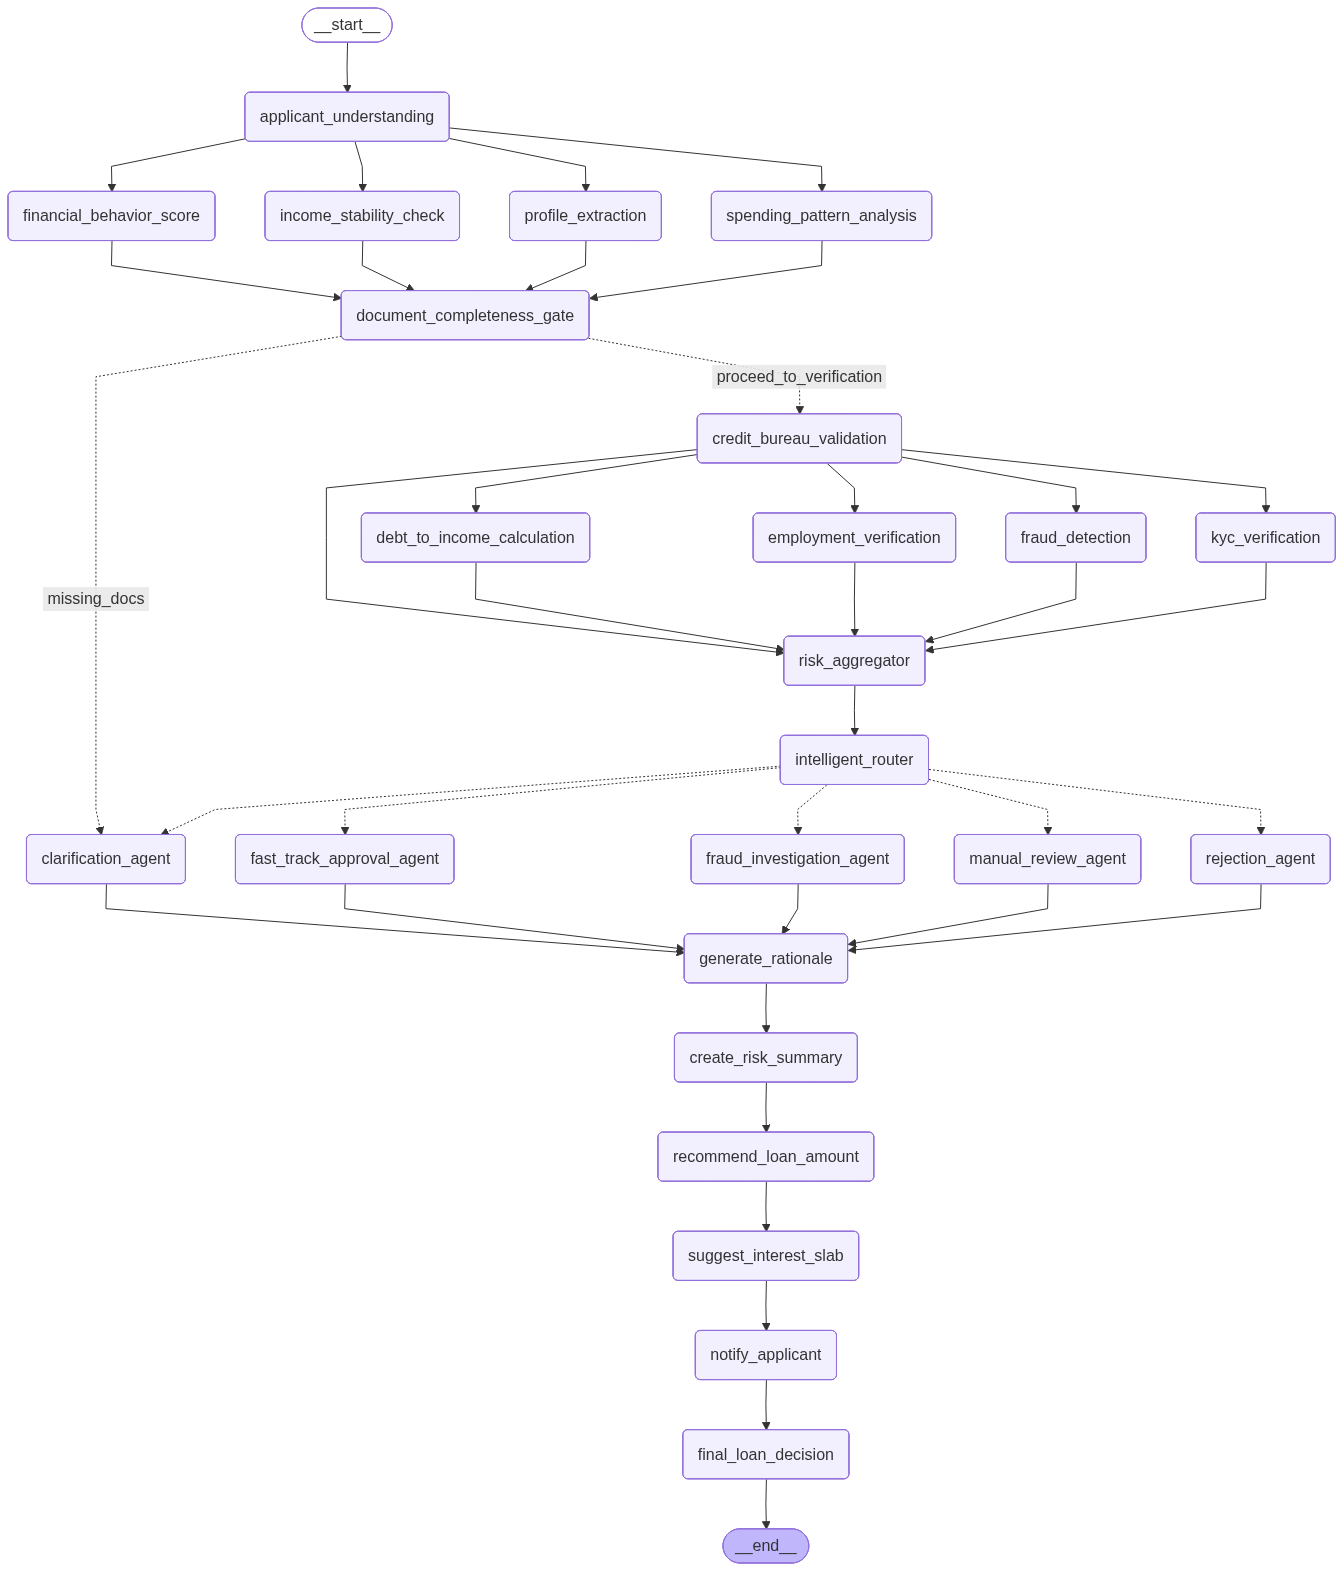

In [68]:
loan_workflow = graph.compile()
loan_workflow


### Test Cases

In [75]:
#Test Case 1:
# Excellent credit, salaried, low debt, full documents
result_1 = loan_workflow.invoke({
    "application_text": """
        Name: Priya Sharma
        I am a salaried software engineer with a monthly income of ₹1,20,000.
        I am requesting a home loan of ₹40,00,000 over 15 years.
        My credit score is 810. I have no existing EMIs or loans.
        I have been working with the same company for 6 years.
    """,
    "documents_provided": "salary slip, bank statement, id proof, address proof, form 16, offer letter"
})


╔══════════════════════════════════════════════════════════════════════╗
║           INTELLIGENT LOAN RISK ASSESSMENT — FINAL REPORT          ║
╚══════════════════════════════════════════════════════════════════════╝

APPLICANT : Priya Sharma
DECISION  : APPROVED
ROUTE     : Fast Track Approval Agent

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — APPLICATION PROFILE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Employment Type     : salaried
  Monthly Income      : ₹120,000
  Loan Requested      : ₹4,000,000
  Tenure              : 15 years
  Existing Debts/EMI  : ₹0/month
  Credit Score        : 810
  Income Stability    : Stable
  Spending Pattern    : Conservative
  Behaviour Score     : 95/100

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — RISK ASSESSMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric                         Value                Risk Tag    
────

In [76]:
#Test Case 2:
# Medium risk, self-employed, moderate DTI
result_2 = loan_workflow.invoke({
    "application_text": """
        Name: Raj Mehta
        Self-employed business owner. Monthly income approximately ₹80,000
        (variable). Requesting a business loan of ₹25,00,000 over 7 years.
        Credit score is around 680. I have existing EMIs of ₹22,000/month.
        Business has been running for 3 years.
    """,
    "documents_provided": "bank statement, id proof, address proof, itr, gst registration,salary slip"
})


╔══════════════════════════════════════════════════════════════════════╗
║           INTELLIGENT LOAN RISK ASSESSMENT — FINAL REPORT          ║
╚══════════════════════════════════════════════════════════════════════╝

APPLICANT : Raj Mehta
DECISION  : REJECTED
ROUTE     : Rejection Agent

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — APPLICATION PROFILE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Employment Type     : self_employed
  Monthly Income      : ₹80,000
  Loan Requested      : ₹2,500,000
  Tenure              : 7 years
  Existing Debts/EMI  : ₹22,000/month
  Credit Score        : 680
  Income Stability    : Stable
  Spending Pattern    : Moderate
  Behaviour Score     : 68/100

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — RISK ASSESSMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric                         Value                Risk Tag    
─────────────